#### What is a KDE Plot (kdeplot)?
A KDE plot is a visualization tool used to show the probability density of a continuous numerical variable. While a histogram uses discrete bins to represent frequency, a KDE plot creates a smooth, continuous curve to represent the distribution.

You can think of it this way: at every single data point, a small "kernel" (typically a Gaussian bell curve) is placed. The KDE plot is the sum of all these individual kernels, creating a smooth curve that estimates the probability density. The height of the curve at any given point represents the density of data points around that value.

Key Difference from a Histogram: A histogram's shape is highly dependent on the number and width of the bins you choose. A KDE plot is less dependent on user choices (though it does have a bandwidth parameter that controls smoothness) and can provide a clearer, less "blocky" picture of the distribution's shape.

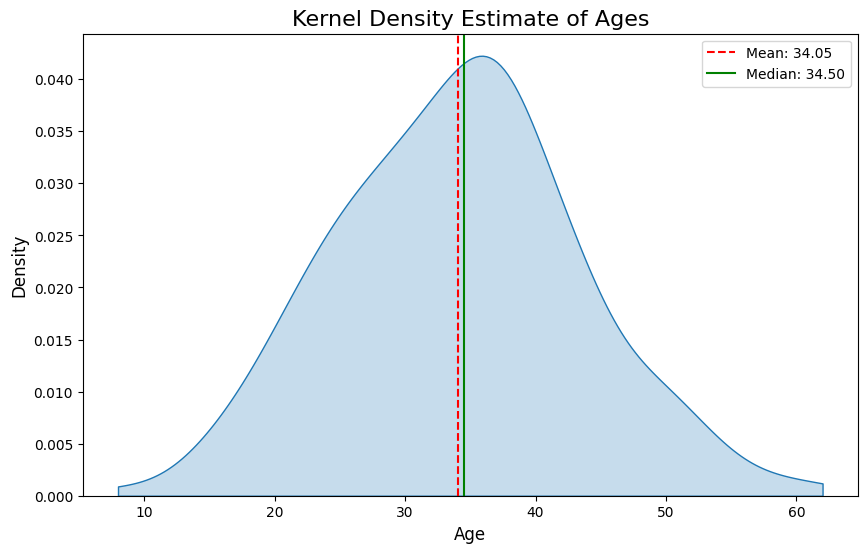

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Sample Data
np.random.seed(42) # for reproducibility
ages = np.random.normal(loc=35, scale=10, size=200).astype(int)
ages = np.clip(ages, 0, 100)
df = pd.DataFrame({'age': ages})

# 2. Sample Code for the Plot
plt.figure(figsize=(10, 6))

# Create the KDE plot using seaborn's kdeplot
# data: The DataFrame
# x: The numerical column to plot
# fill: If True, shades the area under the curve.
# cut: Extends the curve beyond the min/max data points.
sns.kdeplot(
    data=df,
    x='age',
    fill=True, # Shade the area under the curve for better visualization
    cut=0 # Don't extend the curve beyond the data range
)

# Add vertical lines for mean and median for context
plt.axvline(x=df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.2f}")
plt.axvline(x=df['age'].median(), color='green', linestyle='-', label=f"Median: {df['age'].median():.2f}")

# Add title and labels for clarity
plt.title('Kernel Density Estimate of Ages', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12) # Note the y-axis is 'Density', not 'Count'
plt.legend()
plt.show()

#### What Type of Information It Provides
A KDE plot provides the same core insights as a histogram but often with more clarity and nuance.

Shape of the Distribution: This is its primary strength. The smooth curve makes it very easy to identify the shape:

Symmetric / Normal
Skewed (Right or Left)
Bimodal / Multimodal: The presence of multiple distinct peaks is often much clearer in a KDE plot than in a histogram, where the peaks might be split across different bins.
Central Tendency (Mode): The peak(s) of the KDE curve represent the mode(s) of the data—the most frequent values.

Relative Density: It shows where the data points are most concentrated. A higher value on the y-axis means a higher concentration of data points around that x-value.

Important Note on the Y-Axis: Unlike a histogram where the y-axis is a simple frequency count, the y-axis of a KDE plot is "Density". The values are scaled such that the total area under the curve is equal to 1. This represents a probability distribution.

#### Scenarios for Using a KDE Plot
A KDE plot is used in many of the same scenarios as a histogram but is often preferred when the shape of the distribution is the primary interest.

#####  During Exploratory Data Analysis (EDA)
- High-Clarity Distribution Analysis: It's the best tool for clearly visualizing the shape of a single numerical variable's distribution.
Identifying Multiple Modes: It is superior to a histogram for detecting bimodal or multimodal distributions, which can indicate the presence of distinct sub-groups in your data.
- Comparing Distributions: This is a key strength. Using the hue parameter to overlay multiple KDE plots on the same axes is an excellent way to compare the distributions of a variable across different categories. It's often much cleaner than overlaying multiple histograms.
Example: sns.kdeplot(data=df, x='income', hue='region') to see if the income distribution in the 'North' region is different from the 'South' region.
- 2D KDE Plots: KDE plots can also be used to show the density of two numerical variables simultaneously, creating a contour plot that shows where the data is most concentrated in a 2D space. This can be an alternative to a scatter plot when you have a very large number of overlapping points.
Example: sns.kdeplot(data=df, x='study_hours', y='exam_score')
##### During Model Diagnostics and Evaluation
Visualizing Residuals: Just like a histogram, you can plot a KDE of your model's residuals (errors). The KDE plot can provide a clearer picture of whether the errors are truly centered at zero and follow a normal distribution.
##### Communicating Findings
- Smoother Presentations: The smooth, clean look of a KDE plot often makes it a more aesthetically pleasing and easier-to-interpret choice for reports and presentations compared to a "blocky" histogram.

When a Histogram Might Be Better
- When you need exact counts: If the goal is to show the exact number of observations in a specific range, a histogram is better because its y-axis is a direct frequency count.
- When communicating to a non-technical audience: The concept of "counting things in buckets" (histogram) can be more intuitive than "probability density" (KDE plot).